In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\DELL\Downloads\rossmann-store-sales\store.csv")

In [3]:
data

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [4]:
data.shape

(1115, 10)

In [5]:
data.size

11150

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [8]:
data.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [9]:
data.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

## 1. store type

### StoreType represents different categories of Rossmann stores. The exact business meaning of store types (A, B, C, and D) is not publicly disclosed
### in the dataset documentation. Therefore, they are treated as categorical labels during the analysis.

In [10]:
data['StoreType'].unique()

array(['c', 'a', 'd', 'b'], dtype=object)

In [11]:
data['StoreType'].value_counts()

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

## 2. Assortment :- How may different varieties of product are avaiblabel

###  Assortment	Meaning
### a	Basic assortment
### b	Extra assortment
### c	Extended assortment

In [12]:
data['Assortment'].unique()

array(['a', 'c', 'b'], dtype=object)

In [13]:
data['Assortment'].value_counts()

Assortment
a    593
c    513
b      9
Name: count, dtype: int64

## 3. Competition Distance:-distance in meters to the nearest competitor store.

In [14]:
data['CompetitionDistance'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1115 entries, 0 to 1114
Series name: CompetitionDistance
Non-Null Count  Dtype  
--------------  -----  
1112 non-null   float64
dtypes: float64(1)
memory usage: 8.8 KB


In [15]:
data['CompetitionDistance'].isnull().sum()

np.int64(3)

In [16]:
data['CompetitionDistance'].describe()

count     1112.000000
mean      5404.901079
std       7663.174720
min         20.000000
25%        717.500000
50%       2325.000000
75%       6882.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64

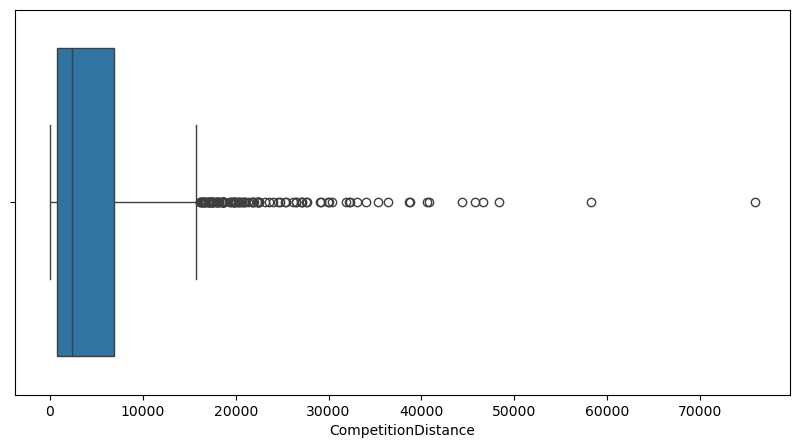

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data,x='CompetitionDistance',orient='Horizontal')
plt.show()

In [24]:
data["CompetitionDistance"].skew()

np.float64(2.9292856455312055)

#### The CompetitionDistance feature is highly positively skewed, indicating that most stores have nearby competitors, while only a small number
### of stores have competitors located much farther away. This suggests the presence of high-distance outliers in the dataset.

## 4.CompetitionOpenSinceMonth

In [25]:
data['CompetitionOpenSinceMonth'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1115 entries, 0 to 1114
Series name: CompetitionOpenSinceMonth
Non-Null Count  Dtype  
--------------  -----  
761 non-null    float64
dtypes: float64(1)
memory usage: 8.8 KB


In [26]:
data['CompetitionOpenSinceMonth'].isnull().sum()

np.int64(354)

In [29]:
data['CompetitionOpenSinceMonth'].value_counts().sort_index()

CompetitionOpenSinceMonth
1.0      14
2.0      41
3.0      70
4.0      94
5.0      44
6.0      50
7.0      67
8.0      39
9.0     125
10.0     61
11.0     92
12.0     64
Name: count, dtype: int64

In [30]:
data['CompetitionOpenSinceMonth'].describe()

count    761.000000
mean       7.224704
std        3.212348
min        1.000000
25%        4.000000
50%        8.000000
75%       10.000000
max       12.000000
Name: CompetitionOpenSinceMonth, dtype: float64

## 5.CompetitionOpenSinceYear	

In [31]:
data['CompetitionOpenSinceYear'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1115 entries, 0 to 1114
Series name: CompetitionOpenSinceYear
Non-Null Count  Dtype  
--------------  -----  
761 non-null    float64
dtypes: float64(1)
memory usage: 8.8 KB


In [32]:
data['CompetitionOpenSinceYear'].isnull().sum()

np.int64(354)

In [33]:
data['CompetitionOpenSinceYear'].value_counts()

CompetitionOpenSinceYear
2013.0    83
2012.0    82
2014.0    70
2005.0    62
2010.0    55
2008.0    54
2009.0    54
2011.0    54
2007.0    48
2006.0    47
2015.0    38
2002.0    27
2004.0    22
2003.0    19
2001.0    16
2000.0    10
1999.0     8
1990.0     5
1995.0     2
1994.0     2
1961.0     1
1900.0     1
1998.0     1
Name: count, dtype: int64

## 6.Promo2:-Store's long-term recurring promotion membership

In [34]:
data['Promo2'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1115 entries, 0 to 1114
Series name: Promo2
Non-Null Count  Dtype
--------------  -----
1115 non-null   int64
dtypes: int64(1)
memory usage: 8.8 KB


In [35]:
data['Promo2'].isnull().sum()

np.int64(0)

In [36]:
data['Promo2'].unique()

array([0, 1])

In [37]:
data['Promo2'].value_counts()

Promo2
1    571
0    544
Name: count, dtype: int64

## 7.Promo2SinceWeek	

In [38]:
data['Promo2SinceWeek'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1115 entries, 0 to 1114
Series name: Promo2SinceWeek
Non-Null Count  Dtype  
--------------  -----  
571 non-null    float64
dtypes: float64(1)
memory usage: 8.8 KB


In [44]:
data['Promo2SinceWeek'].isnull().sum()

np.int64(544)

In [47]:
data[data['Promo2']==0]['Promo2SinceWeek'].isnull().sum()

np.int64(544)

### All 544 stores with Promo2 = 0 have missing values in Promo2SinceWeek. This is a logical missing pattern rather than a data quality issue,
### as stores not participating in the continuous promotional program do not have a promotion start week.

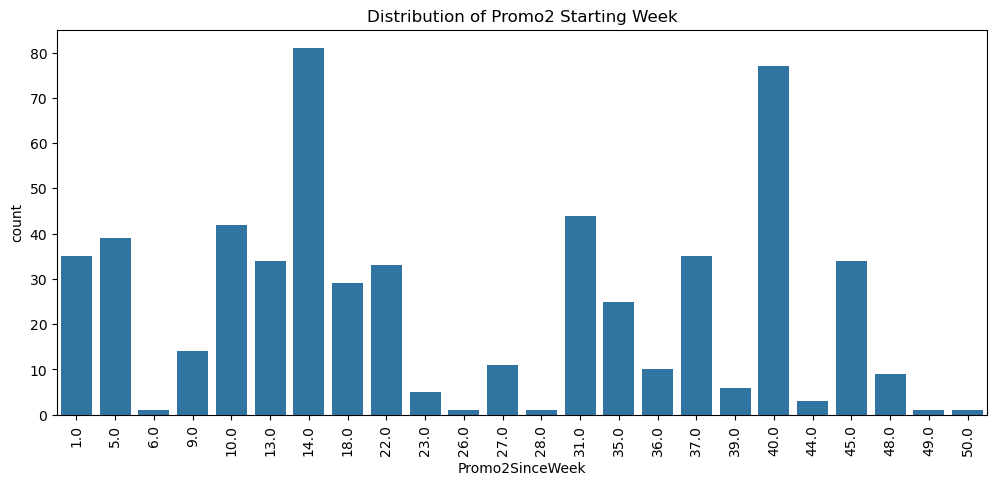

In [49]:
plt.figure(figsize=(12,5))

ax = sns.countplot(
    data=data,
    x="Promo2SinceWeek",
    order=sorted(data["Promo2SinceWeek"].dropna().unique())
)

plt.xticks(rotation=90)

plt.title("Distribution of Promo2 Starting Week")

plt.show()

## 8.Promo2SinceYear	

In [50]:
data['Promo2SinceYear'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1115 entries, 0 to 1114
Series name: Promo2SinceYear
Non-Null Count  Dtype  
--------------  -----  
571 non-null    float64
dtypes: float64(1)
memory usage: 8.8 KB


In [51]:
data['Promo2SinceYear'].isnull().sum()

np.int64(544)

In [52]:
data[data['Promo2']==0]['Promo2SinceYear'].isnull().sum()

np.int64(544)

## 9.PromoInterval:-tells in which months the continuous promotional campaign (Promo2) is active every year.

In [53]:
data['PromoInterval'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1115 entries, 0 to 1114
Series name: PromoInterval
Non-Null Count  Dtype 
--------------  ----- 
571 non-null    object
dtypes: object(1)
memory usage: 8.8+ KB


In [54]:
data['PromoInterval'].isnull().sum()

np.int64(544)

In [55]:
data['PromoInterval'].value_counts()

PromoInterval
Jan,Apr,Jul,Oct     335
Feb,May,Aug,Nov     130
Mar,Jun,Sept,Dec    106
Name: count, dtype: int64

In [56]:
data[data['Promo2']==0]['PromoInterval'].isnull().sum()

np.int64(544)

### The missing values in Promo2SinceWeek, Promo2SinceYear, and PromoInterval are completely explained by stores where Promo2 = 0.
### Therefore, these are business-driven (logical) missing values rather than data quality issues.